In [1]:
import os
os.chdir("../")

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


from solidification.configs.train_fno_pi import Configs
configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})




In [3]:
save_fig_dir = "./figures/"

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


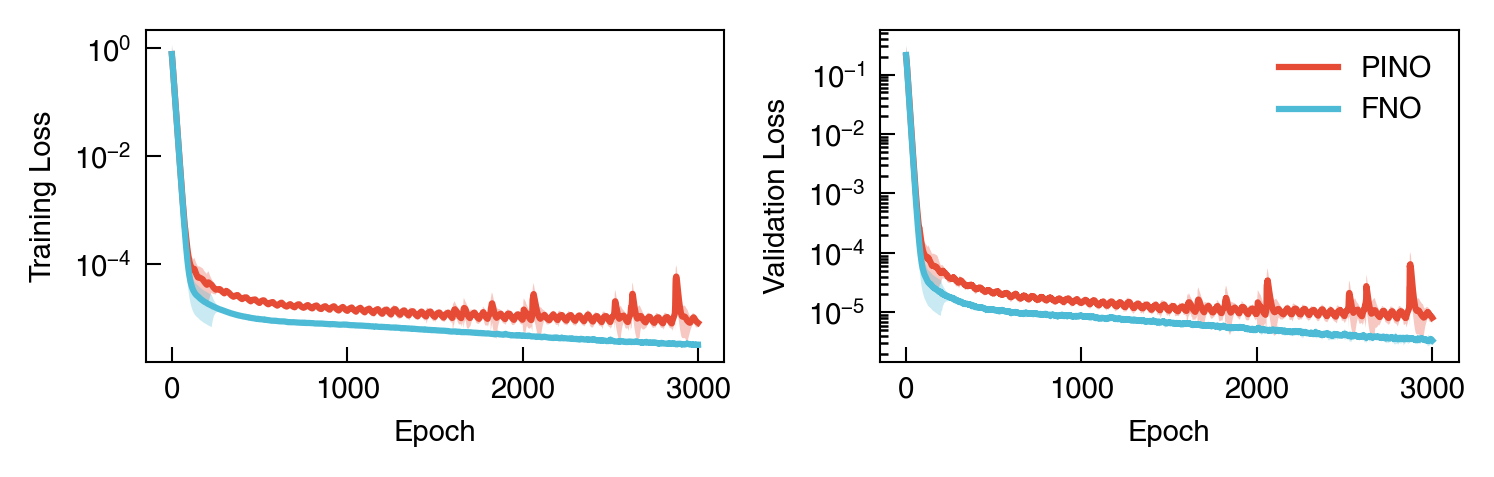

In [4]:
# read csv loss
import pandas as pd
save_dir_pino = "/root/autodl-tmp/runs/solidification/FNO-PI/"
save_dir_fno = "/root/autodl-tmp/runs/solidification/FNO/"
dirs = [
    (save_dir_pino, "PINO"),
    (save_dir_fno, "FNO"),
]
import numpy as np
def smooth_and_ci_ewma(series, alpha=0.1):
    """使用指数加权移动平均，对异常值不敏感"""
    s = pd.Series(np.asarray(series, dtype=float))
    
    # 处理异常值
    s = s.replace([0, np.inf, -np.inf], np.nan)
    # s = s.fillna(method='ffill').fillna(method='bfill')
    s = s.ffill().bfill()
    
    # 指数加权移动平均
    ewm_mean = s.ewm(alpha=alpha, adjust=False).mean().to_numpy()
    ewm_std = s.ewm(alpha=alpha, adjust=False).std().to_numpy()
    
    # 限制置信区间
    ewm_std = np.nan_to_num(ewm_std)
    ci = np.minimum(1.96 * ewm_std, 0.6 * np.abs(ewm_mean))
    
    return ewm_mean, ci


fig, axes = plt.subplots(1, 2, figsize=(5.0, 1.6),)
for idx, (dir_path, model_name) in enumerate(dirs):
    loss_df = pd.read_csv(os.path.join(dir_path, "logs.csv"))
    loss_df = loss_df[loss_df["Epoch"] <= 3000]
    ax = axes[0]
    # ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label=model_name)
    avg, ci = smooth_and_ci_ewma(loss_df["TrainLoss"].values, alpha=0.1)
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], avg - ci, avg + ci, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    
    ax = axes[1]
    # ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label=model_name)
    avg, ci = smooth_and_ci_ewma(loss_df["ValidLoss"].values, alpha=0.1)
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], avg - ci, avg + ci, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    
    ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "solidification_training_validation_loss.pdf"), dpi=300, bbox_inches='tight', pad_inches=0.0)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


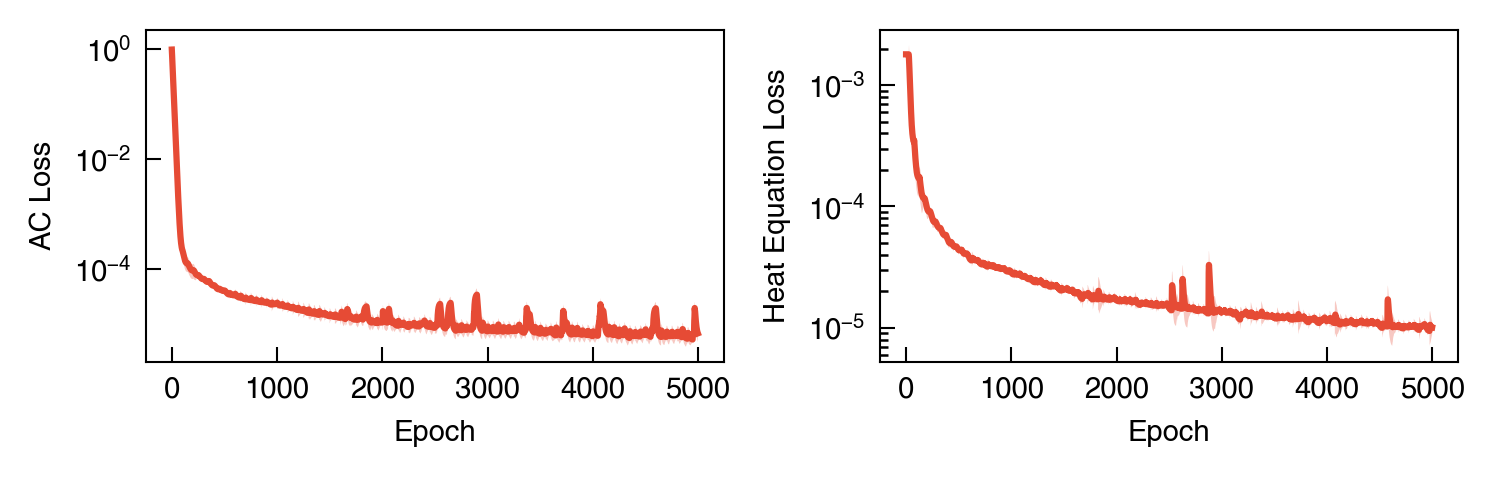

In [5]:
def smooth_and_ci_ewma(series, alpha=0.1):
    """使用指数加权移动平均，对异常值不敏感"""
    s = pd.Series(np.asarray(series, dtype=float))
    
    # 处理异常值
    s = s.replace([0, np.inf, -np.inf], np.nan)
    # s = s.fillna(method='ffill').fillna(method='bfill')
    s = s.ffill().bfill()
    
    # 指数加权移动平均
    ewm_mean = s.ewm(alpha=alpha, adjust=False).mean().to_numpy()
    ewm_std = s.ewm(alpha=alpha, adjust=False).std().to_numpy()
    
    # 限制置信区间
    ewm_std = np.nan_to_num(ewm_std)
    ci = np.minimum(1.96 * ewm_std, 0.3 * np.abs(ewm_mean))
    
    return ewm_mean, ci

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 1.6))
pino_loss_df = pd.read_csv(os.path.join(save_dir_pino, "logs.csv"))

ax = axes[0]
mean, ci = smooth_and_ci_ewma(pino_loss_df["ACLoss"].values, alpha=0.1)
ax.plot(pino_loss_df["Epoch"], mean, label="PINO")
ax.fill_between(pino_loss_df["Epoch"], mean - ci, mean + ci, alpha=0.3)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("AC Loss")

ax = axes[1]
mean, ci = smooth_and_ci_ewma(pino_loss_df["TEMLoss"].values, alpha=0.1)
ax.plot(pino_loss_df["Epoch"], mean, label="PINO")
ax.fill_between(pino_loss_df["Epoch"], mean - ci, mean + ci, alpha=0.3)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Heat Equation Loss")

fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "solidification_ac_tem_loss.pdf"), dpi=300, bbox_inches='tight', pad_inches=0.0)

Text(0, 0.5, 'Test MSE Loss (200 steps)')

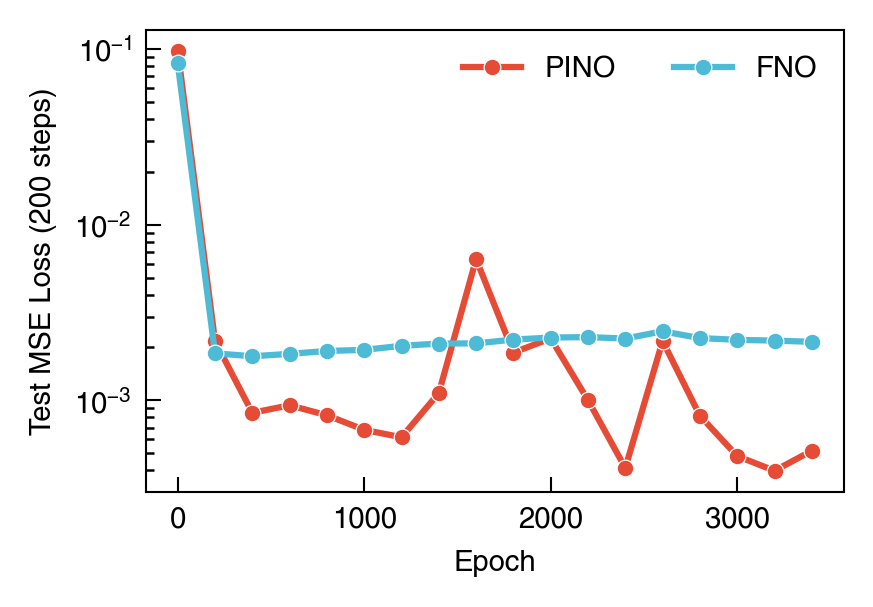

In [6]:

fig, ax = plt.subplots(1, 1, figsize=(3.0, 2.0))
epochs = np.arange(0, 3401, 200)
for dir_path, model_name in dirs:
    # test_df = pd.read_csv(os.path.join(dir_path, "test_logs.csv"))
    test_mse = np.load(os.path.join(dir_path, "test_mse.npy"))
    ax.plot(epochs, test_mse, label=model_name, marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)
    

ax.legend(ncol=2)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test MSE Loss (200 steps)")

## 加载模型并绘制

In [7]:
save_fig_dir = "./figures/"

In [8]:
# from model import model1d
from solidification.model2d import get_model2d

model_kwargs = {
   'modes_x': configs.modes_x,
   'modes_y': configs.modes_x,
   'width': configs.width,
   'depth': configs.depth,
   'activation': getattr(jax.nn, configs.activation),
   'key': jax.random.PRNGKey(0),
}


model_skeleton = get_model2d(
   configs.model_type,
   configs.in_channels,
   configs.out_channels,
   **model_kwargs
)

weight_pino = os.path.join(save_dir_pino, f"epoch_3200.eqx")
model_pino = eqx.tree_deserialise_leaves(weight_pino, model_skeleton)
weight_fno = os.path.join(save_dir_fno, f"epoch_3200.eqx")
model_fno = eqx.tree_deserialise_leaves(weight_fno, model_skeleton)

In [9]:
# data = jnp.load("./dataset_split.npz")
data = jnp.load(os.path.join(configs.data_dir, "dataset_split.npz"))

# Xs, Ys = data["train_x"], data["train_y"]
Xs, Ys = data["valid_x"], data["valid_y"]
meshes = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["meshes"]
times = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["times"]
dt = times[1] - times[0]
# meshes = jnp.transpose(meshes, (2, 0, 1))
meshesx = meshes[0]
meshesy = meshes[1]
Xs.shape, Ys.shape

((250, 5, 129, 129), (250, 2, 129, 129))

In [10]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))
test_ks = jnp.load(os.path.join(configs.test_data_dir, "K_values.npy")).reshape(-1, 1)
u0 = test_solutions[:, 0, :, :]
y_test = test_solutions[:, 1:, :, :]
auto_reg_fn = partial(
    model_pino.auto_reg,
    meshes=meshes,
    steps=200
)
u_preds = jax.vmap(auto_reg_fn)(u0, test_ks)

auto_reg_fn_fno = partial(
    model_fno.auto_reg,
    meshes=meshes,
    steps=200
)
u_preds_fno = jax.vmap(auto_reg_fn_fno)(u0, test_ks)

u_preds.shape, u_preds_fno.shape

((4, 200, 2, 129, 129), (4, 200, 2, 129, 129))

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


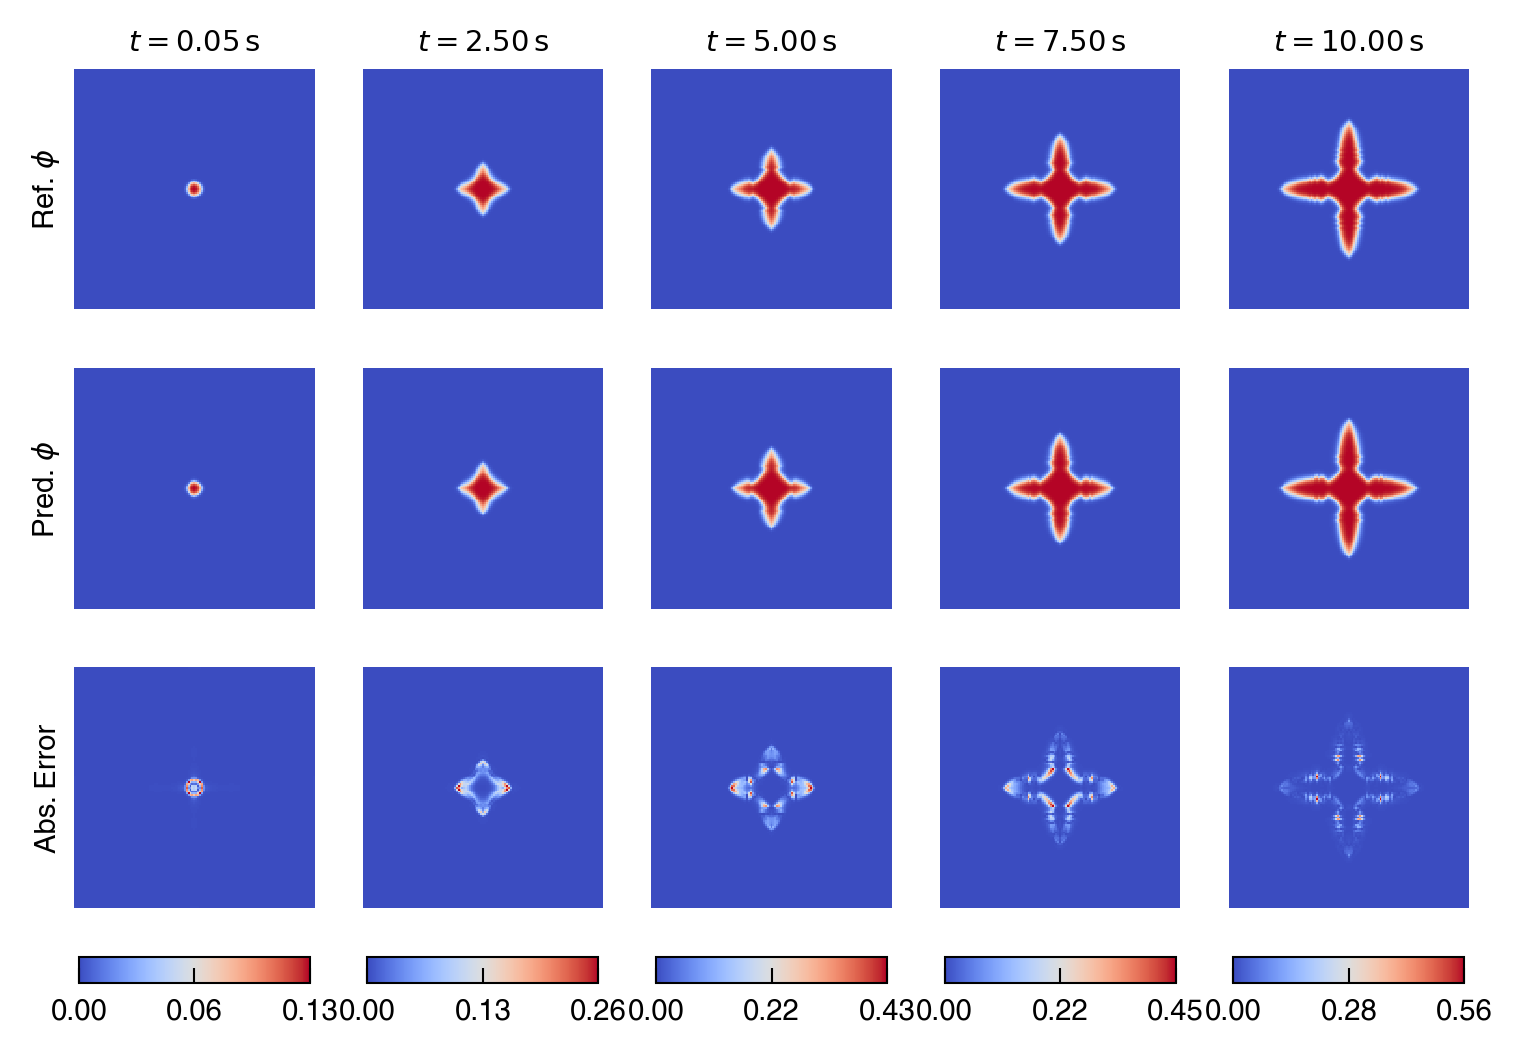

In [11]:
idxs = [0, 49, 99, 149, 199]
meshesx = meshes[0]
meshesy = meshes[1]
example_th = 1
component = 0

def num_to_latex(num, precision=2):
    mantissa, exponent = f"{num:.{precision}e}".split("e")
    exponent = int(exponent)
    return f"{mantissa}\\times 10^{{{exponent}}}"


from matplotlib import gridspec
fig = plt.figure(figsize=(1.2 * len(idxs), 4.0))
gs = gridspec.GridSpec(4, len(idxs), figure=fig,
                       width_ratios=[1]*len(idxs),
                       wspace=0.2,hspace=0.2,
                       height_ratios=[1,1,1,0.1,]
                       )
for i, idx in enumerate(idxs):
    ax = fig.add_subplot(gs[0, i])
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Ref. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.text(0.5, 1.05, rf"$t={(idx+1)*dt*configs.Tc:.2f}\,\mathrm{{s}}$",
            ha="center", va="bottom", transform=ax.transAxes)
    
    ax.set_aspect('equal')

    # ax = fig.add_subplot(gs[1, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[1, i])
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[2, i])
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, 
                            shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[3, i])
    ax.set_axis_off()
    cax = ax.inset_axes([0.02, 0.0, 0.96, 1.0])
    fig.colorbar(diff_ax, cax=cax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))
    
    # ax = fig.add_subplot(gs[5, i]) # this is a empty row for spacing

    # ax = fig.add_subplot(gs[6, i])
    # ax.pcolormesh(meshesx, meshesy, u_preds_fno[example_th, idx, component, :, :], 
    #               shading='auto', cmap='coolwarm', rasterized=True)
    # if i == 0:
    #     ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_axis_off()
    # ax.set_aspect('equal')

    # ax = fig.add_subplot(gs[7, i])
    # diff_fno = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds_fno[example_th, idx, component, :, :])
    # # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    # diff_ax_fno = ax.pcolormesh(meshesx, meshesy, diff_fno, 
    #                         shading='auto', cmap='coolwarm', rasterized=True)
    # if i == 0:
    #     ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_axis_off()
    # ax.set_aspect('equal')

    # ax = fig.add_subplot(gs[8, i])
    # ax.set_axis_off()
    # cax = ax.inset_axes([0.05, 0.0, 0.9, 1.0])
    # fig.colorbar(diff_ax_fno, cax=cax, orientation='horizontal', 
    #              format='%.2f', ticks=jnp.linspace(0, jnp.max(diff_fno), num=3))
    
fig.savefig(os.path.join(save_fig_dir, "solidification_test_sol.pdf"), bbox_inches='tight',
            dpi=450, pad_inches=0.0)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


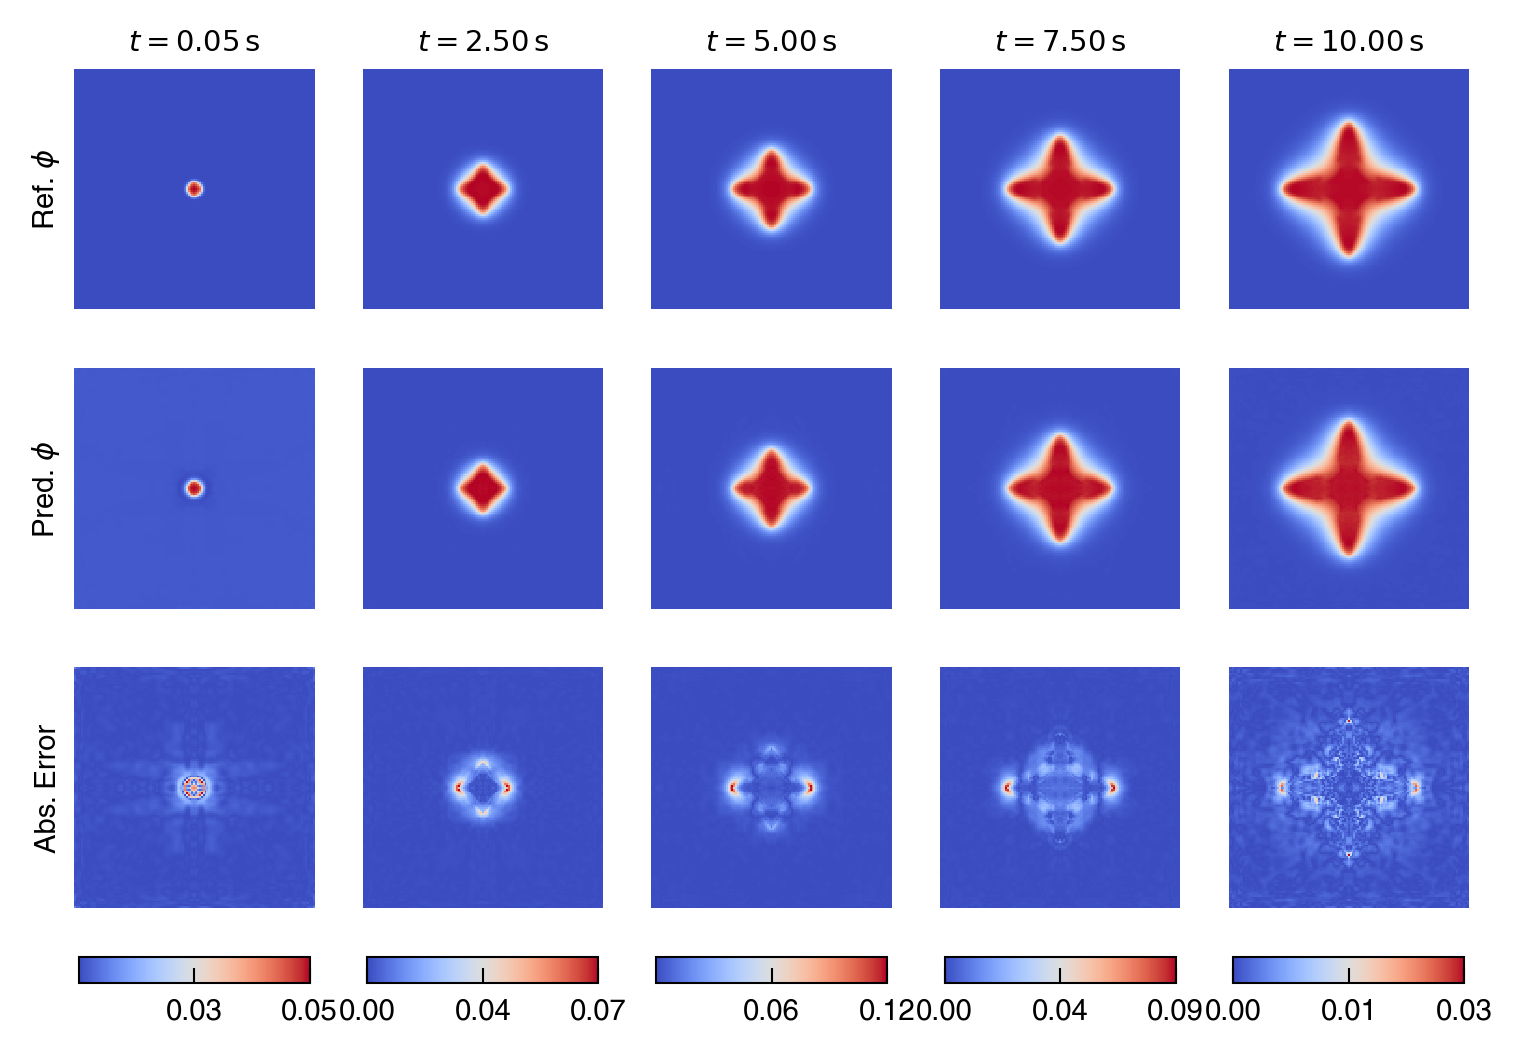

In [12]:
idxs = [0, 49, 99, 149, 199]
meshesx = meshes[0]
meshesy = meshes[1]
example_th = 1
component = 1

def num_to_latex(num, precision=2):
    mantissa, exponent = f"{num:.{precision}e}".split("e")
    exponent = int(exponent)
    return f"{mantissa}\\times 10^{{{exponent}}}"


from matplotlib import gridspec
fig = plt.figure(figsize=(1.2 * len(idxs), 4.0))
gs = gridspec.GridSpec(4, len(idxs), figure=fig,
                       width_ratios=[1]*len(idxs),
                       wspace=0.2,hspace=0.2,
                       height_ratios=[1,1,1,0.1,]
                       )
for i, idx in enumerate(idxs):
    ax = fig.add_subplot(gs[0, i])
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Ref. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.text(0.5, 1.05, rf"$t={(idx+1)*dt*configs.Tc:.2f}\,\mathrm{{s}}$",
            ha="center", va="bottom", transform=ax.transAxes)
    
    ax.set_aspect('equal')

    # ax = fig.add_subplot(gs[1, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[1, i])
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[2, i])
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, 
                            shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[3, i])
    ax.set_axis_off()
    cax = ax.inset_axes([0.02, 0.0, 0.96, 1.0])
    fig.colorbar(diff_ax, cax=cax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))
    
    # ax = fig.add_subplot(gs[5, i]) # this is a empty row for spacing

    # ax = fig.add_subplot(gs[6, i])
    # ax.pcolormesh(meshesx, meshesy, u_preds_fno[example_th, idx, component, :, :], 
    #               shading='auto', cmap='coolwarm', rasterized=True)
    # if i == 0:
    #     ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_axis_off()
    # ax.set_aspect('equal')

    # ax = fig.add_subplot(gs[7, i])
    # diff_fno = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds_fno[example_th, idx, component, :, :])
    # # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    # diff_ax_fno = ax.pcolormesh(meshesx, meshesy, diff_fno, 
    #                         shading='auto', cmap='coolwarm', rasterized=True)
    # if i == 0:
    #     ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_axis_off()
    # ax.set_aspect('equal')

    # ax = fig.add_subplot(gs[8, i])
    # ax.set_axis_off()
    # cax = ax.inset_axes([0.05, 0.0, 0.9, 1.0])
    # fig.colorbar(diff_ax_fno, cax=cax, orientation='horizontal', 
    #              format='%.2f', ticks=jnp.linspace(0, jnp.max(diff_fno), num=3))
    
fig.savefig(os.path.join(save_fig_dir, "solidification_test_sol_t.pdf"), bbox_inches='tight',
            dpi=450, pad_inches=0.0)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


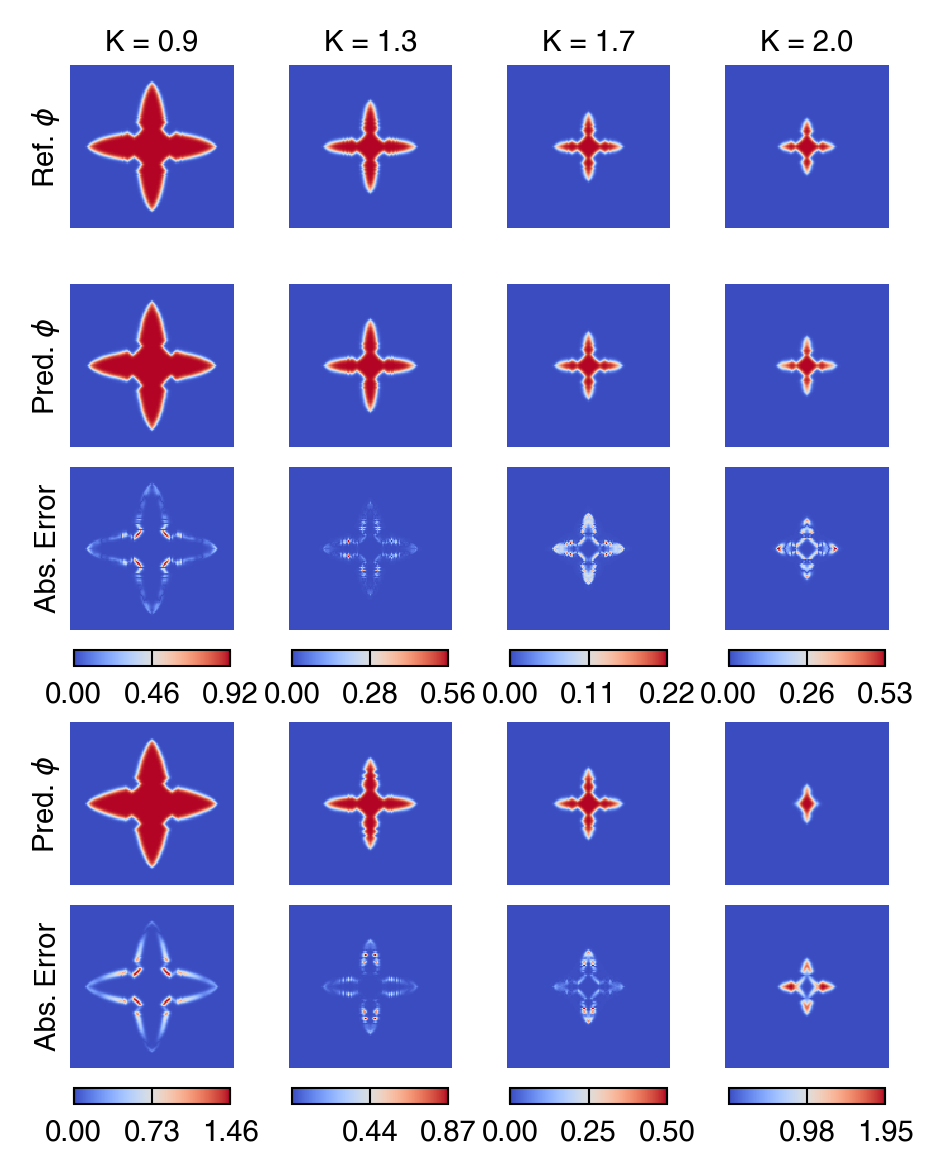

In [11]:
# Final time step, with different ks

meshesx = meshes[0]
meshesy = meshes[1]
example_ths = [0, 1, 2, 3]
idx = -1
component = 0
from matplotlib import gridspec
fig = plt.figure(figsize=(0.9 * len(example_ths), 4.5))
gs = gridspec.GridSpec(9, len(example_ths), figure=fig,
                       width_ratios=[1]*len(example_ths),
                    #    wspace=0.2,hspace=0.2,
                       height_ratios=[1,0.1,1,1,0.1,0.1,1,1,0.1]
                       )
for i, example_th in enumerate(example_ths):
    ax = fig.add_subplot(gs[0, i])
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Ref. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"K = {test_ks[example_th, -1]:.1f}", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    # ax = figure.add_subplot(gs[1, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[2, i])
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[3, i])
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[4, i])
    ax.set_axis_off()
    cax = ax.inset_axes([0.07, 0.0, 0.86, 1.0])
    fig.colorbar(diff_ax, cax=cax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))
    
    # ax = figure.add_subplot(gs[5, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[6, i])
    ax.pcolormesh(meshesx, meshesy, u_preds_fno[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[7, i])
    diff_fno = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds_fno[example_th, idx, component, :, :])
    diff_ax_fno = ax.pcolormesh(meshesx, meshesy, diff_fno, shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[8, i])
    ax.set_axis_off()
    cax = ax.inset_axes([0.07, 0.0, 0.86, 1.0])
    fig.colorbar(diff_ax_fno, cax=cax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff_fno), num=3), )
    
fig.savefig(os.path.join(save_fig_dir, "solidification_test_final_shape_phi.pdf"), bbox_inches='tight', dpi=450)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


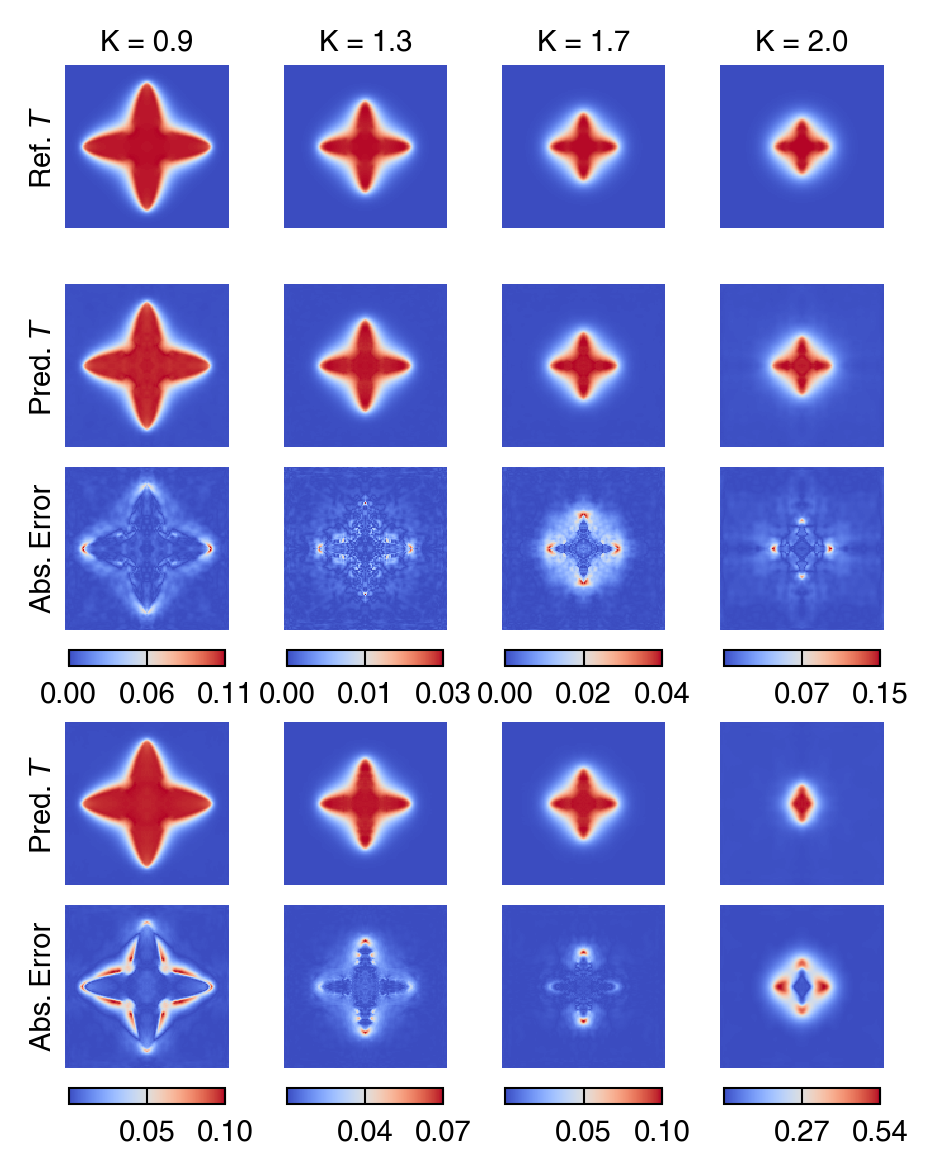

In [12]:

meshesx = meshes[0]
meshesy = meshes[1]
example_ths = [0, 1, 2, 3]
idx = -1
component = 1
from matplotlib import gridspec
fig = plt.figure(figsize=(0.9 * len(example_ths), 4.5))
gs = gridspec.GridSpec(9, len(example_ths), figure=fig,
                       width_ratios=[1]*len(example_ths),
                    #    wspace=0.2,hspace=0.2,
                       height_ratios=[1,0.1,1,1,0.1,0.1,1,1,0.1]
                       )
for i, example_th in enumerate(example_ths):
    ax = fig.add_subplot(gs[0, i])
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Ref. $T$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"K = {test_ks[example_th, -1]:.1f}", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    # ax = figure.add_subplot(gs[1, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[2, i])
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $T$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[3, i])
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[4, i])
    ax.set_axis_off()
    cax = ax.inset_axes([0.07, 0.0, 0.86, 1.0])
    fig.colorbar(diff_ax, cax=cax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))
    
    # ax = figure.add_subplot(gs[5, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[6, i])
    ax.pcolormesh(meshesx, meshesy, u_preds_fno[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $T$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[7, i])
    diff_fno = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds_fno[example_th, idx, component, :, :])
    diff_ax_fno = ax.pcolormesh(meshesx, meshesy, diff_fno, shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[8, i])
    ax.set_axis_off()
    cax = ax.inset_axes([0.07, 0.0, 0.86, 1.0])
    fig.colorbar(diff_ax_fno, cax=cax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff_fno), num=3), )
    
fig.savefig(os.path.join(save_fig_dir, "solidification_test_final_shape_T.pdf"), bbox_inches='tight', dpi=450)

In [13]:
y_test.shape

(4, 200, 2, 129, 129)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


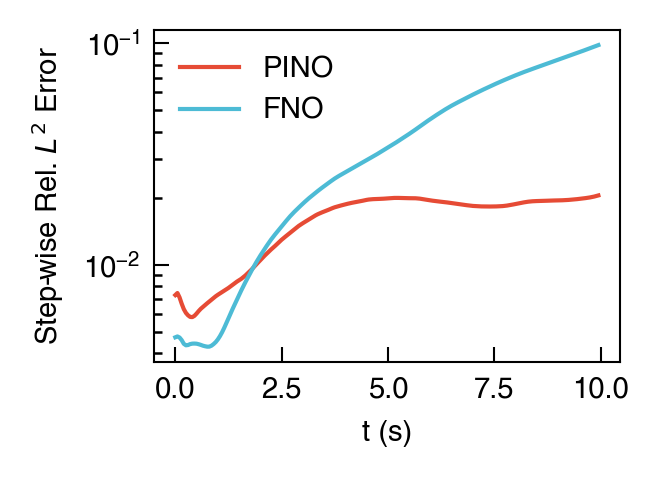

In [14]:

step_wise_l2_pino = jnp.linalg.norm(y_test - u_preds, axis=(-1,-2)) / jnp.linalg.norm(y_test, axis=(-1,-2))
step_wise_l2_fno = jnp.linalg.norm(y_test - u_preds_fno, axis=(-1,-2)) / jnp.linalg.norm(y_test, axis=(-1,-2))
# step_wise_l2_pino = jnp.mean(step_wise_l2_pino[2:], axis=(0, 2)) # avg over samples and channels
# step_wise_l2_fno = jnp.mean(step_wise_l2_fno[2:], axis=(0, 2)) # avg over samples and channels

fig, ax = plt.subplots(1, 1, figsize=(2.2, 1.6))
ts = jnp.arange(step_wise_l2_pino.shape[1]) * dt
# interpolation samples
# ax.plot(ts, jnp.mean(step_wise_l2_pino[:2], axis=(0, 2)), label="PINO-INT", lw=1, color="C0")
# ax.plot(ts, jnp.mean(step_wise_l2_fno[:2], axis=(0, 2)), label="FNO-INT", lw=1, color="C1")

# extrapolation samples
ax.plot(ts, jnp.mean(step_wise_l2_pino[2:], axis=(0, 2)), label="PINO", lw=1, color="C0")
ax.plot(ts, jnp.mean(step_wise_l2_fno[2:], axis=(0, 2)), label="FNO", lw=1,  color="C1")
ax.set_yscale("log")
ax.set_xlabel(r"t (s)")
ax.set_ylabel("Step-wise Rel. $L^2$ Error")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "solidification_stepwise_l2.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)

In [15]:
epochs = jnp.arange(0, 3201, configs.test_every)

l2_pino_list = []
l2_fno_list = []

def compute_l2(model, x_test, y_test, test_meshes, test_ks):
    auto_reg_fn = partial(
        model.auto_reg,
        meshes=test_meshes,
        steps=200,
    )
    y_test_pred = jax.vmap(auto_reg_fn, in_axes=(0, 0))(x_test, test_ks)

    # shape [sample, T, channel, spatialx, spatialy]
    # compute l2 on T, x, y
    # l2 = jnp.linalg.norm(y_test_pred - y_test, axis=(3,4)) / jnp.linalg.norm(y_test, axis=(3,4))
    l2 = jnp.sqrt(jnp.sum((y_test_pred - y_test) ** 2, axis=(1,3,4)) / jnp.sum(y_test ** 2, axis=(1,3,4)))
    l2 = l2[2:]
    l2 = jnp.mean(l2)  # avg over samples and channels
    return l2
    
for epoch in epochs:
    weight_pino = os.path.join(save_dir_pino, f"epoch_{epoch}.eqx")
    model_pino = eqx.tree_deserialise_leaves(weight_pino, model_skeleton)
    l2_pino = compute_l2(model_pino, u0, y_test, meshes, test_ks)
    l2_pino_list.append(l2_pino)
    weight_fno = os.path.join(save_dir_fno, f"epoch_{epoch}.eqx")
    model_fno = eqx.tree_deserialise_leaves(weight_fno, model_skeleton)
    l2_fno = compute_l2(model_fno, u0, y_test, meshes, test_ks)
    l2_fno_list.append(l2_fno)


2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Minimum L2 errors during training:
PINO: 0.01721767708659172
FNO: 0.04848848283290863


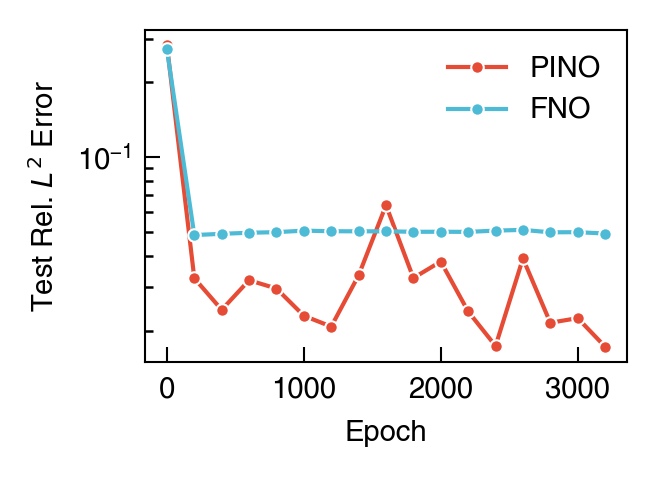

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(2.2, 1.6))
# l2_pino = jnp.array(l2_pino_list) * 0.8
# l2_pino = l2_pino.at[-4].set(l2_pino[-4] * 0.6)
ax.plot(epochs, l2_pino_list, label="PINO", lw=1, marker='o', markersize=3, 
        markeredgecolor="white", markeredgewidth=0.5)
ax.plot(epochs, l2_fno_list, label="FNO", lw=1, marker='o', markersize=3,
        markeredgecolor="white", markeredgewidth=0.5)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Rel. $L^2$ Error")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "solidification_test_l2.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)

print("Minimum L2 errors during training:")
print(f"PINO: {min(l2_pino_list)}")
print(f"FNO: {min(l2_fno_list)}")

In [17]:
print("Minimum L2 errors during training:")
print(f"PINO: {min(l2_pino_list)}")
print(f"FNO: {min(l2_fno_list)}")

Minimum L2 errors during training:
PINO: 0.01721767708659172
FNO: 0.04848848283290863


2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


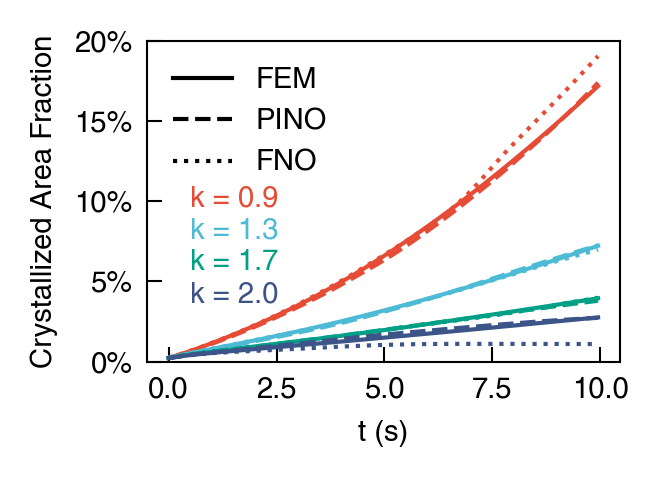

In [18]:
# step-wise volumn of the crystallized region

vol_frac_pino = jnp.mean((u_preds[:, :, 0, :, :]+1)/2, axis=(-1, -2))
vol_frac_fno = jnp.mean((u_preds_fno[:, :, 0, :, :]+1)/2, axis=(-1, -2))
vol_frac_fem = jnp.mean((y_test[:, :, 0, :, :]+1)/2, axis=(-1, -2))

fig, ax = plt.subplots(1, 1, figsize=(2.2, 1.6))
ts = jnp.arange(vol_frac_pino.shape[1]) * dt
for i, example_th in enumerate(example_ths):
    ax.plot(ts, vol_frac_fem[example_th, :], lw=1, color=f"C{i}",)
    ax.plot(ts, vol_frac_pino[example_th, :], lw=1, color=f"C{i}", linestyle='--',)
    ax.plot(ts, vol_frac_fno[example_th, :], lw=1, color=f"C{i}", linestyle=':')

ax.set_xlabel(r"t (s)")
ax.set_ylabel("Crystallized Area Fraction")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
from matplotlib.lines import Line2D 
custom_lines = [
    Line2D([0], [0], color='black', lw=1, linestyle='-'),
    Line2D([0], [0], color='black', lw=1, linestyle='--'),
    Line2D([0], [0], color='black', lw=1, linestyle=':'),
]
ax.legend(custom_lines, ['FEM', 'PINO', 'FNO'], loc='upper left')

ax.set_ylim(0, 0.2)
# manually annotate K values
for i, example_th in enumerate(example_ths):
    # ax.text(10, vol_frac_fem[example_th, -1], f'k={test_ks[example_th, -1]:.1f}', color=f"C{i}")
    ax.text(0.5, 0.11 - i * 0.02, f'k = {test_ks[example_th, -1]:.1f}', color=f"C{i}",
            ha='left', va='top')

fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "solidification_vol_frac.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)


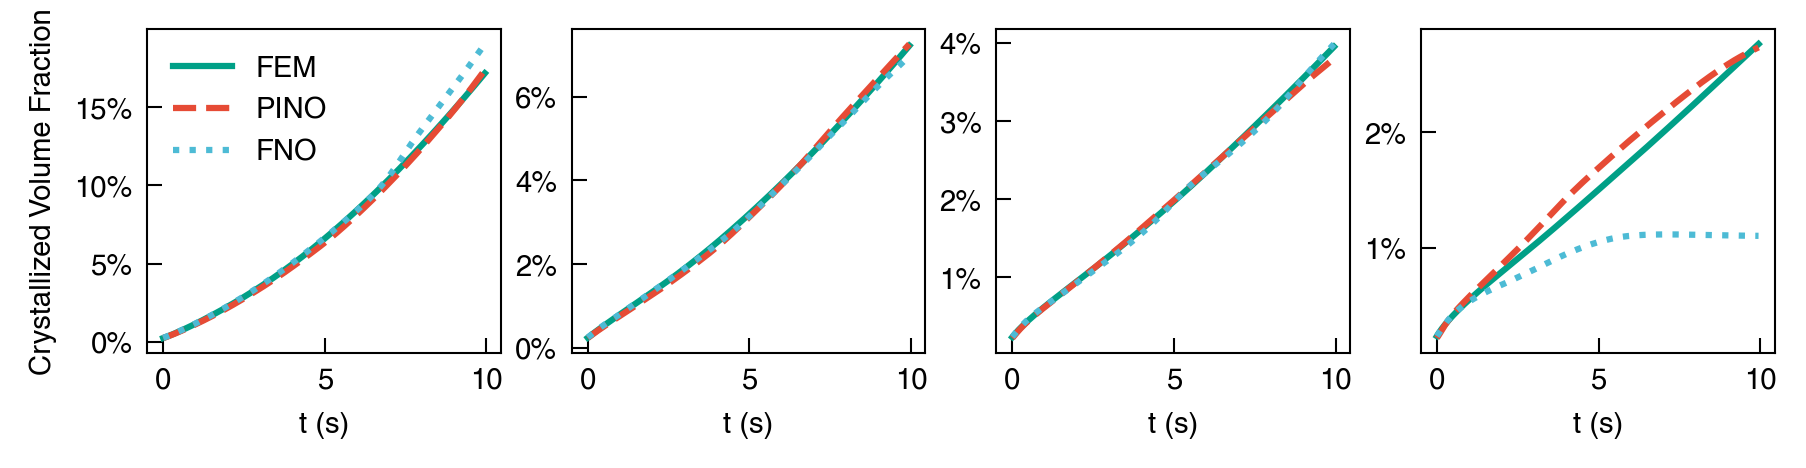

In [19]:
# step-wise volumn of the crystallized region

vol_frac_pino = jnp.mean((u_preds[:, :, 0, :, :]+1)/2, axis=(-1, -2))
vol_frac_fno = jnp.mean((u_preds_fno[:, :, 0, :, :]+1)/2, axis=(-1, -2))
vol_frac_fem = jnp.mean((y_test[:, :, 0, :, :]+1)/2, axis=(-1, -2))

fig, axes = plt.subplots(1, 4, figsize=(7.0, 1.4))
ts = jnp.arange(vol_frac_pino.shape[1]) * dt
lagends = ['FEM', 'PINO', 'FNO']
for ax, example_th in zip(axes, example_ths):
    ax.plot(ts, vol_frac_fem[example_th, :], lw=1.5, label='FEM', color="C2")
    ax.plot(ts, vol_frac_pino[example_th, :], lw=1.5, label='PINO', color="C0", ls='--')
    ax.plot(ts, vol_frac_fno[example_th, :], lw=1.5, label='FNO', color="C1", ls=':')
    ax.set_xlabel(r"t (s)")

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    if example_th == example_ths[0]:
        ax.legend(lagends, loc='upper left')
        ax.set_ylabel("Crystallized Volume Fraction")


